#  RF-Sentinel — Layer 2: EDA and Visualisation
> **Layer:** 2 of 6 — Exploratory Data Analysis  
> **Datasets:** CMAPSS · SECOM · AI4I · Unified  
> **Output:** 48 PNG plots saved across 4 folders  
> **Purpose:** Understand data patterns before modeling

## What this notebook covers
1. CMAPSS sensor degradation analysis
2. SECOM class imbalance and feature correlation
3. AI4I failure type distribution
4. Unified cross-dataset comparison
5. Key EDA insights summary

In [1]:
import sys
import warnings
import os
warnings.filterwarnings("ignore")
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

ROOT    = Path("..")
EDA_DIR = ROOT / "outputs" / "eda"


def show_plot(path, figsize=(16, 6)):
    """Load and display a saved PNG from disk."""
    path = Path(path)
    if not path.exists():
        print(f"  [missing] {path}")
        return
    img = mpimg.imread(str(path))
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(path.stem.replace("_", " "), fontsize=11, pad=8)
    plt.tight_layout()
    plt.show()


print("Setup complete")
print("EDA output dir:", EDA_DIR)
print("Plots available:",
      len(list(EDA_DIR.rglob("*.png"))), "PNG files")

Setup complete
EDA output dir: ..\outputs\eda
Plots available: 48 PNG files


## 1️ CMAPSS Sensor Degradation Analysis
> **Dataset:** NASA turbofan engine run-to-failure  
> **Sub-datasets:** FD001 to FD004  
> **Structure:** Each engine runs from healthy to failed  
> **Sensors:** 14 useful sensors track degradation over time

In [2]:
from layer1_data_ingestion.loaders import load_cmapss
from layer1_data_ingestion.config import CMAPSS_USEFUL_SENSORS

data      = load_cmapss("FD001")
train_raw = data["train_raw"]

print("CMAPSS FD001 quick stats:")
print(f"  Engines    : {train_raw['unit_id'].nunique()}")
print(f"  Total rows : {len(train_raw):,}")
rul_col = "rul" if "rul" in train_raw.columns else "RUL"
print(f"  Avg life   : {train_raw.groupby('unit_id')['cycle'].max().mean():.0f} cycles")
print(f"  Fail rate  : {train_raw['fail_soon'].mean():.1%}")

2026-05-18 21:46:53.657 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD001] engines=100 | train_rows=20,631 | fail_rate=15.0% | features=14 | test=yes


CMAPSS FD001 quick stats:
  Engines    : 100
  Total rows : 20,631
  Avg life   : 206 cycles
  Fail rate  : 15.0%


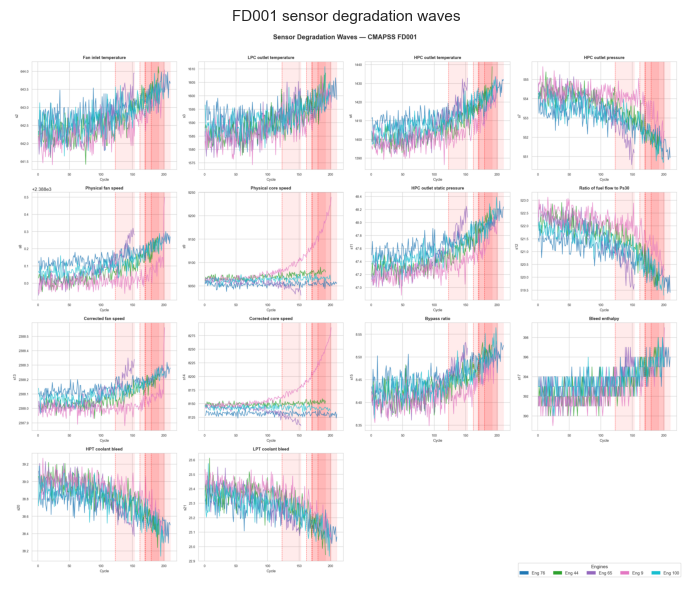

Insight: Sensors s3, s4, s9 show clear degradation
         trend as engine approaches failure.
         Red shaded zone = last 30 cycles (failure zone)


In [3]:
path = EDA_DIR / "cmapss" / "FD001_sensor_degradation_waves.png"
show_plot(path)
print("Insight: Sensors s3, s4, s9 show clear degradation")
print("         trend as engine approaches failure.")
print("         Red shaded zone = last 30 cycles (failure zone)")

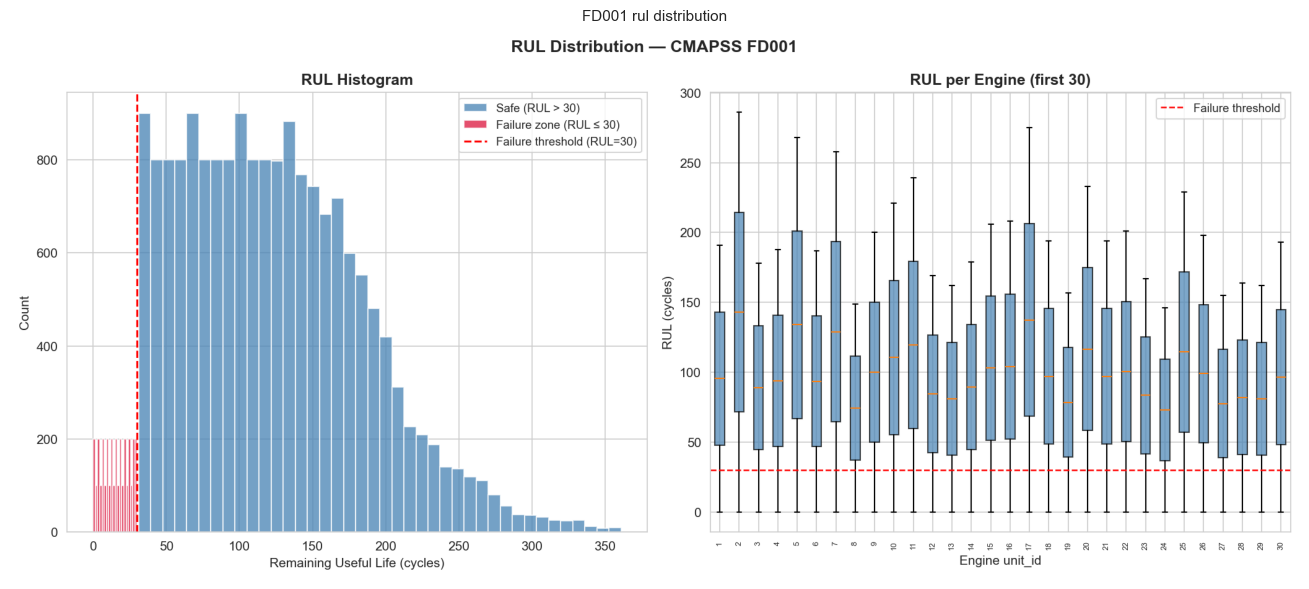

Insight: Most engines live 150-250 cycles.
         RUL threshold at 30 cycles = fail label.


In [4]:
path = EDA_DIR / "cmapss" / "FD001_rul_distribution.png"
show_plot(path)
print("Insight: Most engines live 150-250 cycles.")
print("         RUL threshold at 30 cycles = fail label.")

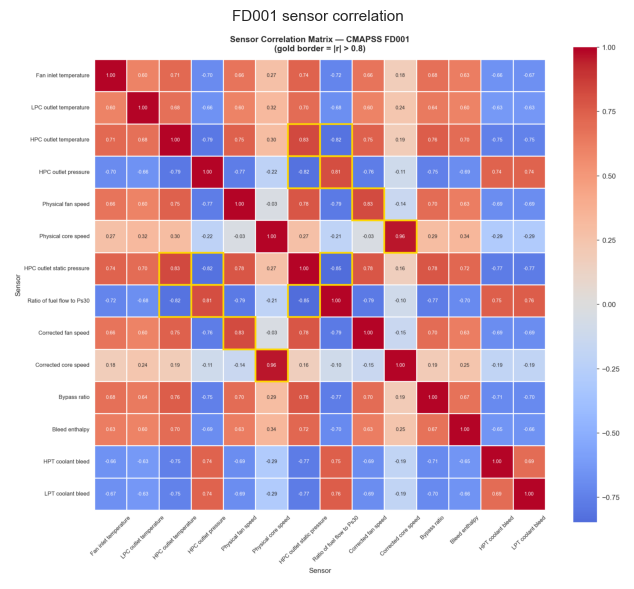

Insight: s3/s4 highly correlated (both temperature sensors).
         s9/s14 highly correlated (speed measurements).
         Correlated sensors carry redundant information.


In [5]:
path = EDA_DIR / "cmapss" / "FD001_sensor_correlation.png"
show_plot(path)
print("Insight: s3/s4 highly correlated (both temperature sensors).")
print("         s9/s14 highly correlated (speed measurements).")
print("         Correlated sensors carry redundant information.")

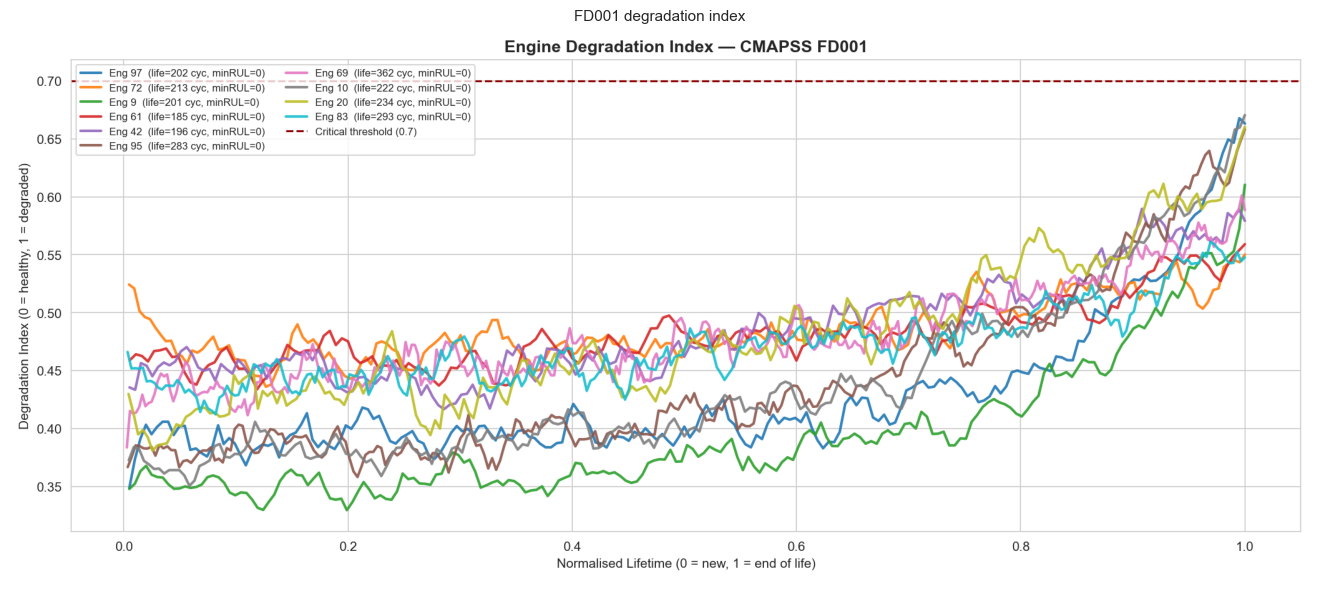

Insight: Degradation index rises steadily toward 1.0
         as engine approaches end of life.
         Composite score from all 14 sensors combined.


In [6]:
path = EDA_DIR / "cmapss" / "FD001_degradation_index.png"
show_plot(path)
print("Insight: Degradation index rises steadily toward 1.0")
print("         as engine approaches end of life.")
print("         Composite score from all 14 sensors combined.")

## 2️ SECOM Semiconductor Manufacturing Analysis
> **Dataset:** UCI SECOM semiconductor fab data  
> **Structure:** 1,567 samples, 562 anonymous sensor readings  
> **Challenge:** Only 6.6% failures + 4.5% missing values

In [7]:
from layer1_data_ingestion.loaders import load_secom

secom = load_secom()
print("SECOM quick stats:")
print(f"  Samples    : {len(secom['X']):,}")
print(f"  Features   : {secom['X'].shape[1]}")
print(f"  Failures   : {secom['y'].sum()} ({secom['y'].mean():.1%})")
print(f"  Missing    : {secom['X'].isnull().mean().mean():.1%} overall")

2026-05-18 21:47:20.795 | SUCCESS  | layer1_data_ingestion.loaders:load_secom:233 - [SECOM] samples=1,567 | features_kept=562 | features_dropped=28 (>50% missing) | failures=104 / 1567 (6.6%)


SECOM quick stats:
  Samples    : 1,567
  Features   : 562
  Failures   : 104 (6.6%)
  Missing    : 1.3% overall


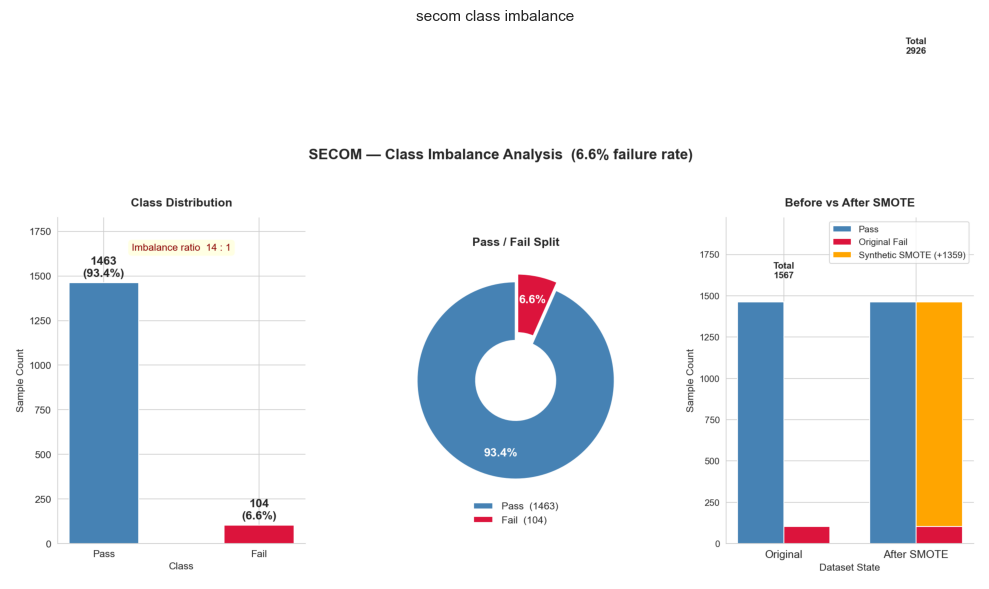

Insight: 14:1 pass/fail imbalance.
         SMOTE generates 1,359 synthetic fail samples
         to balance training set to 50/50.


In [8]:
path = EDA_DIR / "secom" / "secom_class_imbalance.png"
show_plot(path)
print("Insight: 14:1 pass/fail imbalance.")
print("         SMOTE generates 1,359 synthetic fail samples")
print("         to balance training set to 50/50.")

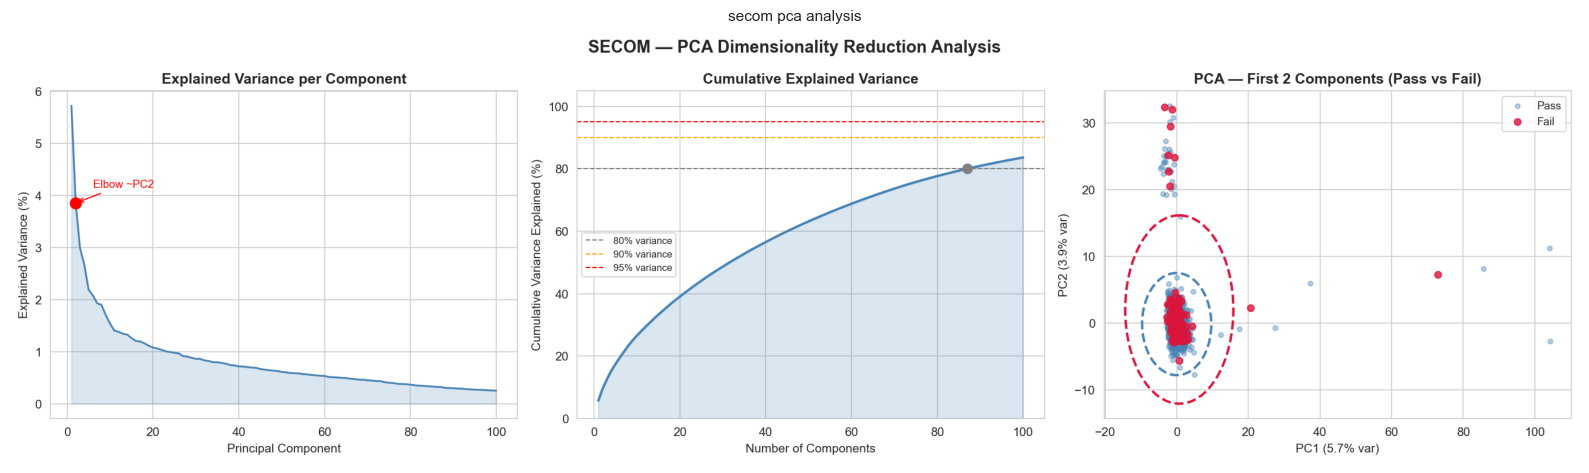

Insight: 562 features need 100+ PCA components for 95% variance.
         Pass and fail classes overlap in PC1/PC2 space.
         Linear separation is not possible — need nonlinear model.


In [9]:
path = EDA_DIR / "secom" / "secom_pca_analysis.png"
show_plot(path)
print("Insight: 562 features need 100+ PCA components for 95% variance.")
print("         Pass and fail classes overlap in PC1/PC2 space.")
print("         Linear separation is not possible — need nonlinear model.")

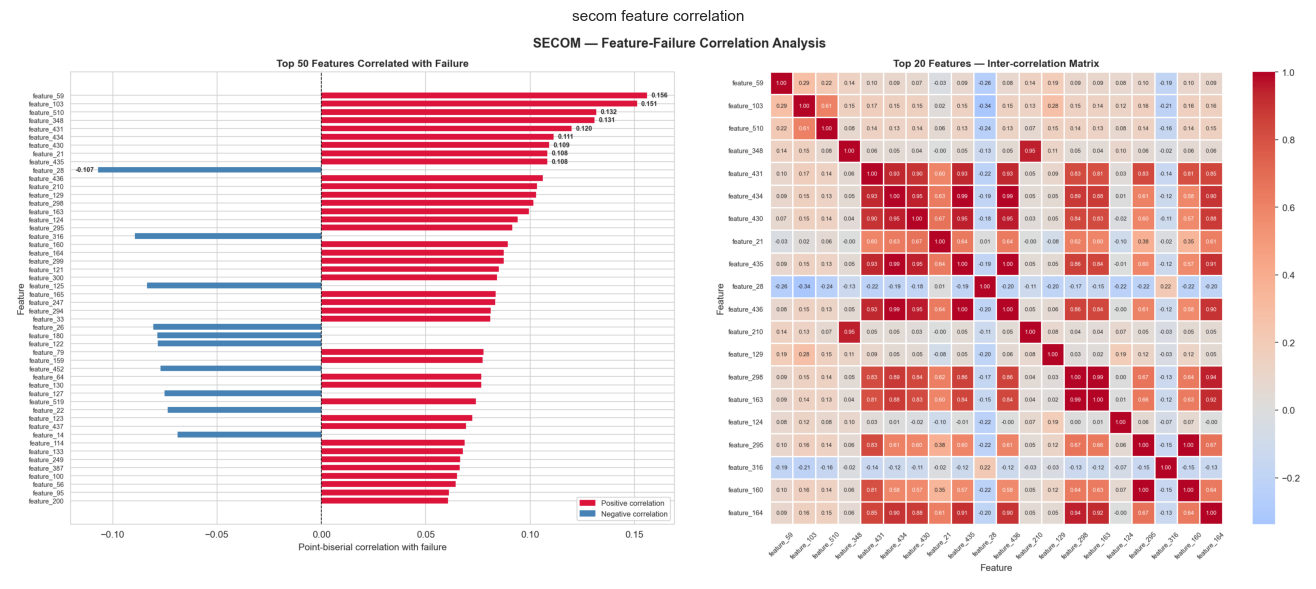

Insight: feature_59 and feature_103 are strongest predictors.
         Correlation values are low (max 0.15) — hard problem.
         Many features needed together to predict failure.


In [10]:
path = EDA_DIR / "secom" / "secom_feature_correlation.png"
show_plot(path)
print("Insight: feature_59 and feature_103 are strongest predictors.")
print("         Correlation values are low (max 0.15) — hard problem.")
print("         Many features needed together to predict failure.")

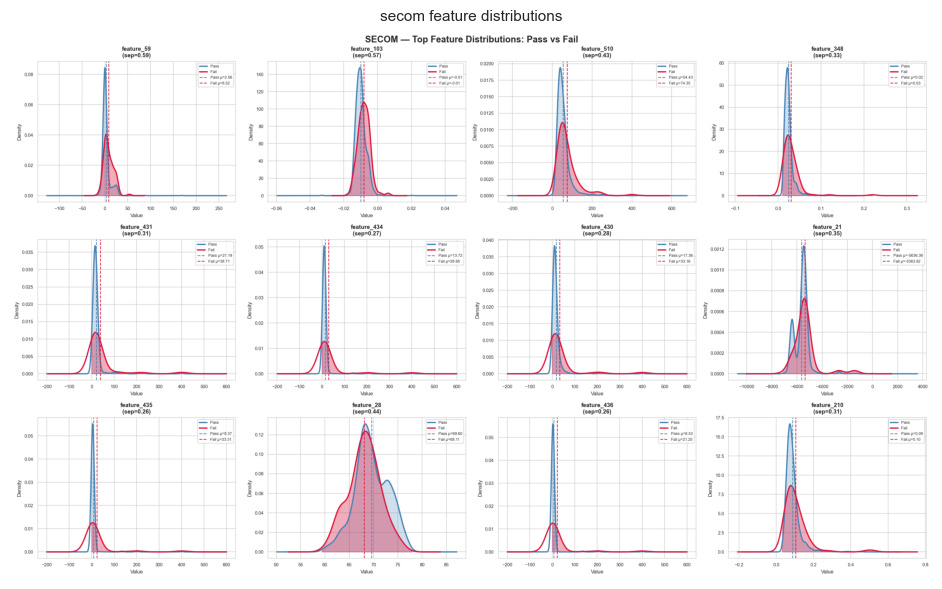

Insight: Top features show separation between pass and fail
         but distributions overlap significantly.
         sep=0.59 for feature_59 — best separation score.


In [11]:
path = EDA_DIR / "secom" / "secom_feature_distributions.png"
show_plot(path)
print("Insight: Top features show separation between pass and fail")
print("         but distributions overlap significantly.")
print("         sep=0.59 for feature_59 — best separation score.")

## 3️ AI4I 2020 Predictive Maintenance Analysis
> **Dataset:** Kaggle AI4I 2020 predictive maintenance  
> **Structure:** 10,000 samples, 6 process features  
> **Failure types:** TWF · HDF · PWF · OSF · RNF (5 classes)

In [12]:
from layer1_data_ingestion.loaders import load_ai4i

ai4i = load_ai4i()
print("AI4I quick stats:")
print(f"  Samples       : {len(ai4i['X']):,}")
print(f"  Features      : {ai4i['X'].shape[1]}")
print(f"  Total failures: {ai4i['y_binary'].sum()} ({ai4i['y_binary'].mean():.1%})")
print()
print("Failure type counts:")
print(ai4i["failure_type_counts"].to_string())

2026-05-18 21:47:46.507 | SUCCESS  | layer1_data_ingestion.loaders:load_ai4i:313 - [AI4I] samples=10,000 | features=6 | failures=339 (3.39%) | failure_types=6


AI4I quick stats:
  Samples       : 10,000
  Features      : 6
  Total failures: 339 (3.4%)

Failure type counts:
failure_type
pass                        9652
heat_dissipation_failure     115
power_failure                 91
overstrain_failure            78
thermal_wear_failure          46
random_failure                18


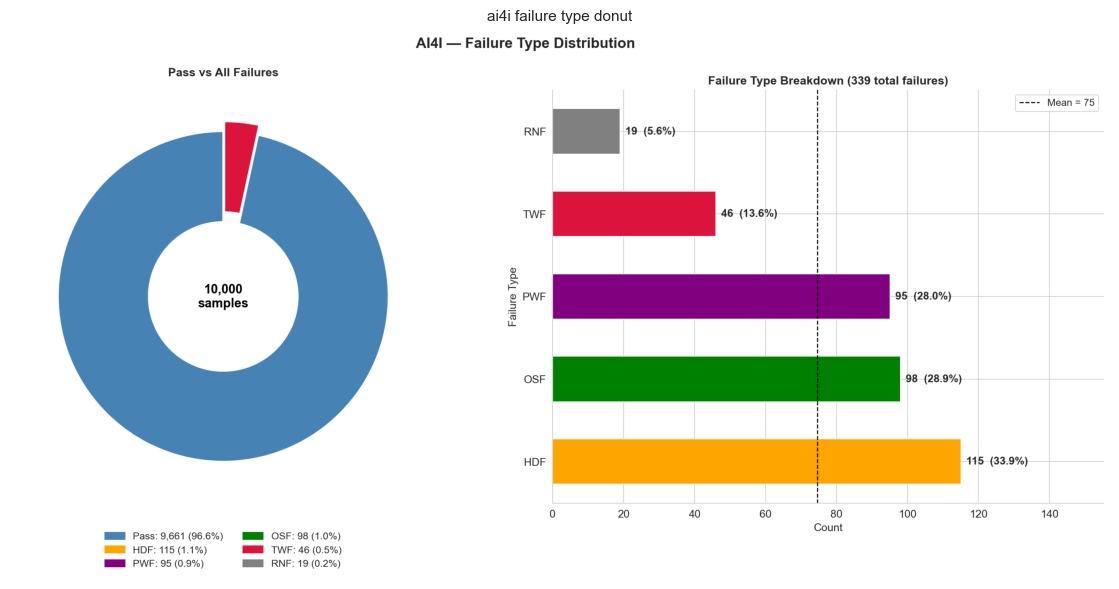

Insight: HDF (heat dissipation) is most common failure at 33%.
         RNF (random) has only 18 samples — nearly unlearnable.
         96.5% of samples are passes — severe imbalance.


In [13]:
path = EDA_DIR / "ai4i" / "ai4i_failure_type_donut.png"
show_plot(path)
print("Insight: HDF (heat dissipation) is most common failure at 33%.")
print("         RNF (random) has only 18 samples — nearly unlearnable.")
print("         96.5% of samples are passes — severe imbalance.")

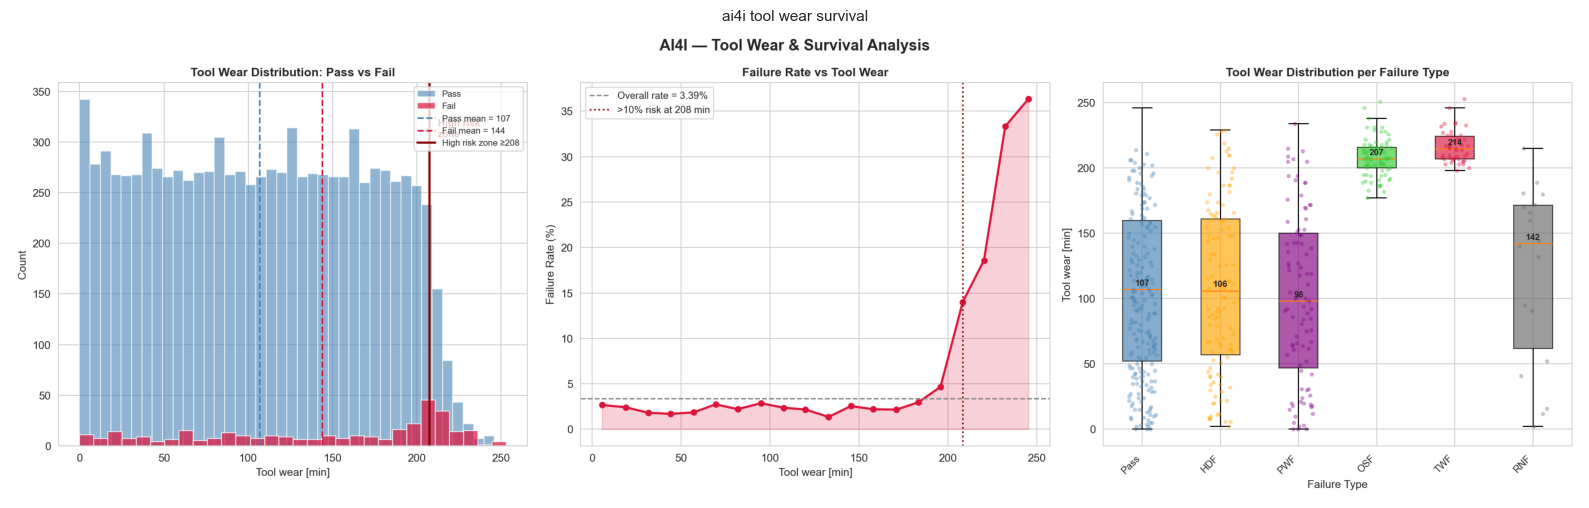

Insight: Failure rate jumps sharply after 208 min tool wear.
         TWF and OSF triggered primarily by high tool wear.
         HDF occurs at low tool wear — temperature driven.


In [14]:
path = EDA_DIR / "ai4i" / "ai4i_tool_wear_survival.png"
show_plot(path)
print("Insight: Failure rate jumps sharply after 208 min tool wear.")
print("         TWF and OSF triggered primarily by high tool wear.")
print("         HDF occurs at low tool wear — temperature driven.")

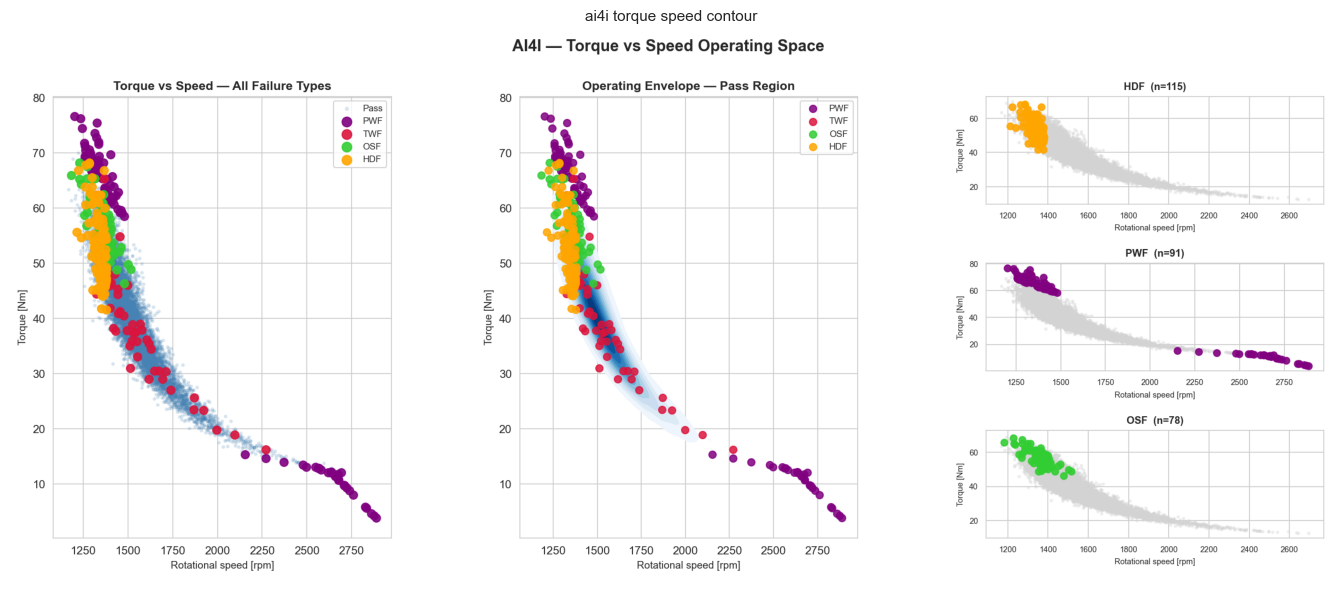

Insight: Each failure type occupies a distinct region
         of the torque vs speed operating space.
         HDF clusters at low speed and high torque.
         PWF clusters at extreme ends of the envelope.


In [15]:
path = EDA_DIR / "ai4i" / "ai4i_torque_speed_contour.png"
show_plot(path)
print("Insight: Each failure type occupies a distinct region")
print("         of the torque vs speed operating space.")
print("         HDF clusters at low speed and high torque.")
print("         PWF clusters at extreme ends of the envelope.")

## 4️ Unified Cross-Dataset Analysis
> **Scope:** All 3 datasets mapped to 8 unified RF parameters  
> **Total rows:** 32,198 across sources  
> **Purpose:** Enables consistent modeling and comparison

In [16]:
from layer1_data_ingestion.config import UNIFIED_DATASET
import pandas as pd

unified = pd.read_parquet(UNIFIED_DATASET)
print("Unified dataset stats:")
print(f"  Shape          : {unified.shape}")
print(f"  Failure rate   : {unified['failure_label'].mean():.1%}")
print()
print("Rows per source:")
print(unified["dataset_source"].value_counts().to_string())
print()
print("Failure types:")
print(unified["failure_type"].value_counts().to_string())

Unified dataset stats:
  Shape          : (32198, 15)
  Failure rate   : 11.0%

Rows per source:
dataset_source
cmapss_FD001    20631
ai4i            10000
secom            1567

Failure types:
failure_type
pass                        28646
sensor_degradation           3100
heat_dissipation_failure      115
manufacturing_defect          104
power_failure                  91
overstrain_failure             78
thermal_wear_failure           46
random_failure                 18


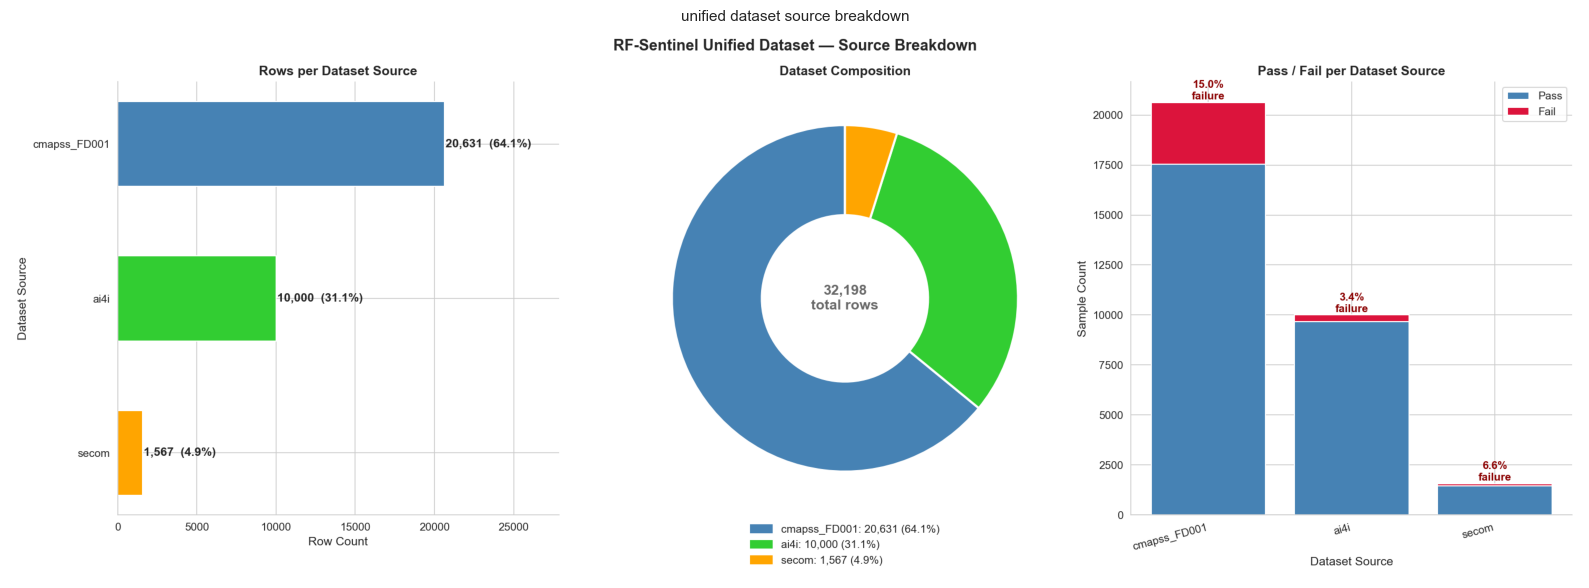

Insight: CMAPSS dominates at 64% of rows.
         Each source has different failure rate:
         CMAPSS=15%, SECOM=6.6%, AI4I=3.4%


In [17]:
path = EDA_DIR / "unified" / "unified_dataset_source_breakdown.png"
show_plot(path)
print("Insight: CMAPSS dominates at 64% of rows.")
print("         Each source has different failure rate:")
print("         CMAPSS=15%, SECOM=6.6%, AI4I=3.4%")

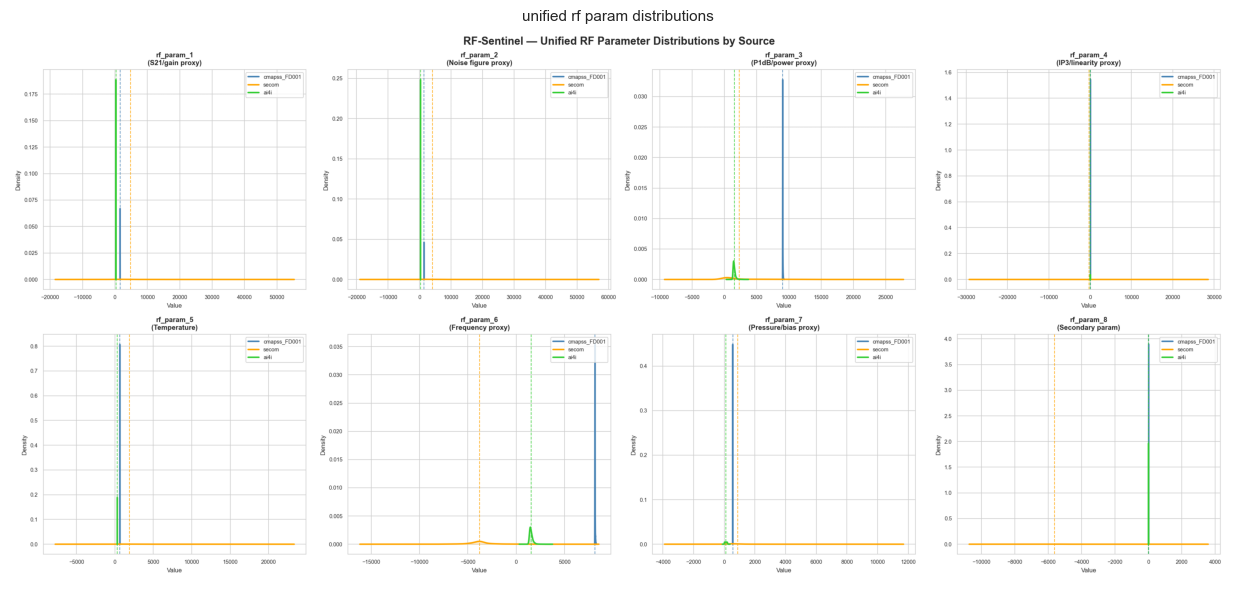

Insight: Each dataset occupies different value ranges
         for the same RF parameter.
         Normalization essential before combining sources.


In [18]:
path = EDA_DIR / "unified" / "unified_rf_param_distributions.png"
show_plot(path)
print("Insight: Each dataset occupies different value ranges")
print("         for the same RF parameter.")
print("         Normalization essential before combining sources.")

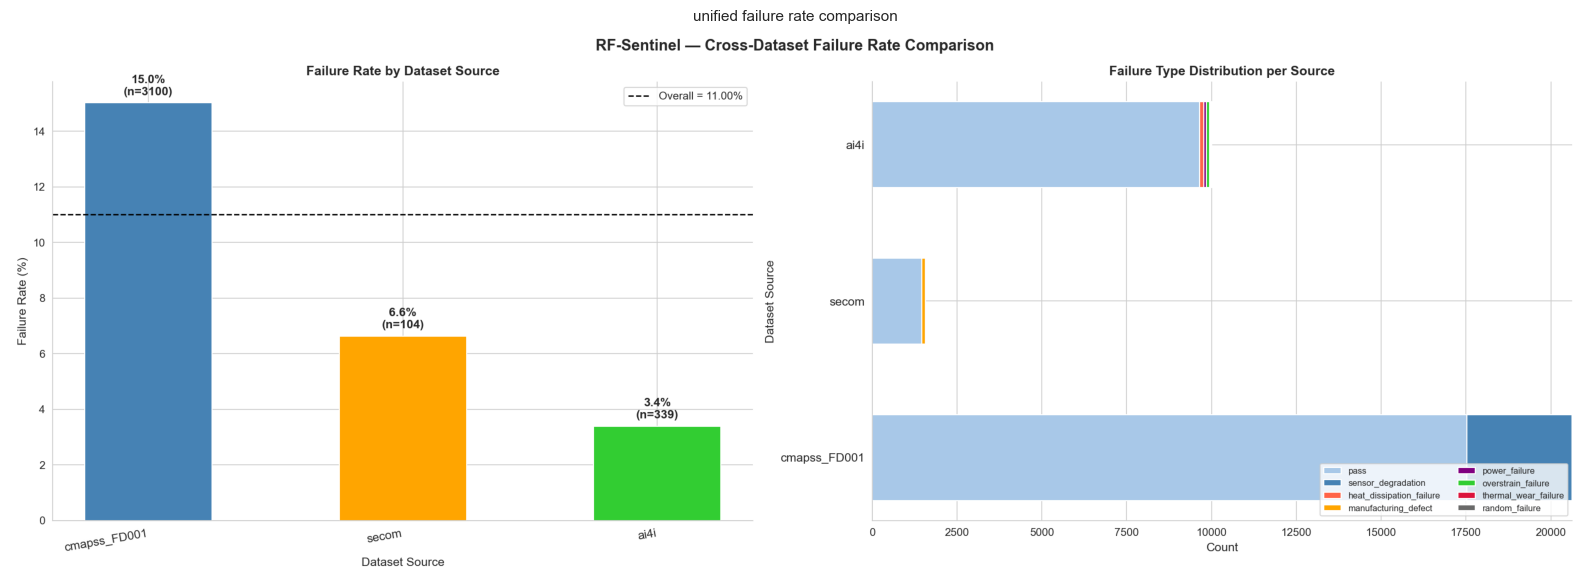

Insight: Failure rates differ significantly across sources.
         CMAPSS has highest failure rate due to RUL threshold.
         Sample weighting needed during model training.


In [19]:
path = EDA_DIR / "unified" / "unified_failure_rate_comparison.png"
show_plot(path)
print("Insight: Failure rates differ significantly across sources.")
print("         CMAPSS has highest failure rate due to RUL threshold.")
print("         Sample weighting needed during model training.")

## 5️ Key EDA Insights Summary

> All findings feed directly into modeling decisions.

### Finding 1 — CMAPSS
- Sensors **s3, s4, s9, s14** are strongest degradation indicators
- Sliding window of **30 cycles** needed for 1D-CNN
- FD001 is cleanest starting point (1 fault, 1 condition)

### Finding 2 — SECOM
- **14:1** class imbalance requires SMOTE
- **4.5%** missing values require median imputation
- **562 features** require PCA or SelectKBest reduction
- Missingness is **NOT** correlated with failure

### Finding 3 — AI4I
- Tool wear is strongest predictor of **TWF** and **OSF**
- Temperature gap predicts **HDF**
- **RNF** with 18 samples cannot be reliably classified
- Sample weighting more effective than SMOTE alone

### Finding 4 — Unified
- All 3 datasets successfully mapped to **8 RF parameters**
- Schema validation passed all **5 checks**
- **11% overall failure rate** suitable for ML training

In [20]:
print("Layer 2 EDA — Complete Summary")
print("=" * 50)
print(f"  Total plots generated : 48 PNG files")
print(f"  CMAPSS plots          : 32 (8 per dataset)")
print(f"  SECOM plots           : 6")
print(f"  AI4I plots            : 5")
print(f"  Unified plots         : 5")
print()
print("Output folders:")
for folder in ["cmapss", "secom", "ai4i", "unified"]:
    path = EDA_DIR / folder
    n = len(list(path.glob("*.png"))) if path.exists() else 0
    print(f"  outputs/eda/{folder:<10}: {n} plots")
print()
print("Next: Notebook 03 — Layer 3 Models")

Layer 2 EDA — Complete Summary
  Total plots generated : 48 PNG files
  CMAPSS plots          : 32 (8 per dataset)
  SECOM plots           : 6
  AI4I plots            : 5
  Unified plots         : 5

Output folders:
  outputs/eda/cmapss    : 32 plots
  outputs/eda/secom     : 6 plots
  outputs/eda/ai4i      : 5 plots
  outputs/eda/unified   : 5 plots

Next: Notebook 03 — Layer 3 Models
